# Motor-imagery EEG decoding: accuracy is only part of the problem

**Author:** Yabsera Negussie  
**Dataset:** PhysioNet EEG Motor Movement/Imagery Database  
**Task:** Classify imagined left- versus right-fist movement from EEG.

I built this analysis to look beyond the best accuracy in a table. Along with decoder performance, I wanted to know how strongly results varied between participants, how much calibration data helped, and whether a smaller motor-region electrode set could preserve the cohort average.

> The saved version contains the final 20-participant run. Run the cells in order to reproduce it.

## 1. Environment setup

This notebook is designed for Google Colab. A GPU is not required. The first command installs the analysis libraries into the temporary Colab runtime.

In [1]:
%pip -q install "mne>=1.7,<2.0" "numpy>=1.26,<3.0" "pandas>=2.1,<3.0" "scikit-learn>=1.4,<2.0" "matplotlib>=3.8,<4.0" "seaborn>=0.13,<1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 30.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [17]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns

from mne.datasets import eegbci
from mne.decoding import CSP
from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")
sns.set_theme(style="whitegrid", context="talk")

RANDOM_STATE = 42
FMIN, FMAX = 8.0, 30.0
TMIN, TMAX = 0.5, 3.5
RUNS = [4, 8, 12]  # imagined left fist versus imagined right fist

# Final portfolio cohort. I used subjects 1–5 first as a pipeline check.
SUBJECTS = list(range(1, 21))

PROJECT_DIR = Path("/content/bci-motor-imagery-benchmark")
DATA_DIR = PROJECT_DIR / "data"
FIGURE_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
for directory in (DATA_DIR, FIGURE_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Participants selected: {SUBJECTS}")
print(f"Outputs will be written to: {PROJECT_DIR}")

Participants selected: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Outputs will be written to: /content/bci-motor-imagery-benchmark


## 2. Load and validate the motor-imagery data

For runs 4, 8, and 12, the `T1` and `T2` annotations represent imagined left- and right-fist movement. Each recording is standardized to conventional EEG channel names, filtered to 8-30 Hz, and segmented from 0.5 to 3.5 seconds after the cue.

Filtering is unsupervised. CSP and classifier fitting will happen inside cross-validation folds to avoid target leakage.

In [18]:
def load_subject_epochs(subject):
    """Download, preprocess, and epoch one PhysioNet participant."""
    file_paths = eegbci.load_data(
        subjects=subject,
        runs=RUNS,
        path=str(DATA_DIR),
        update_path=False,
    )
    raws = [mne.io.read_raw_edf(path, preload=True, verbose=False) for path in file_paths]
    raw = mne.concatenate_raws(raws)
    eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage("standard_1005"), on_missing="ignore")
    raw.filter(FMIN, FMAX, fir_design="firwin", skip_by_annotation="edge", verbose=False)

    events, _ = mne.events_from_annotations(
        raw, event_id={"T1": 1, "T2": 2}, verbose=False
    )
    epochs = mne.Epochs(
        raw,
        events,
        event_id={"left_hand": 1, "right_hand": 2},
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        picks="eeg",
        preload=True,
        reject_by_annotation=True,
        verbose=False,
    )
    X = epochs.get_data(copy=True)
    y = epochs.events[:, -1] - 1
    return epochs, X, y

subject_data = {}
quality_rows = []

for subject in SUBJECTS:
    print(f"Loading subject {subject}...")
    try:
        epochs, X, y = load_subject_epochs(subject)
        subject_data[subject] = {
            "epochs": epochs,
            "X": X,
            "y": y,
            "ch_names": list(epochs.ch_names),
        }
        class_counts = np.bincount(y, minlength=2)
        quality_rows.append({
            "subject": subject,
            "trials": len(y),
            "left_trials": int(class_counts[0]),
            "right_trials": int(class_counts[1]),
            "channels": X.shape[1],
            "time_samples": X.shape[2],
        })
    except Exception as exc:
        print(f"Subject {subject} skipped: {exc}")

quality_df = pd.DataFrame(quality_rows)
if quality_df.empty:
    raise RuntimeError("No subjects loaded. Review the error messages above before continuing.")

display(quality_df)
print(f"Successfully loaded {len(subject_data)} of {len(SUBJECTS)} subjects.")
quality_df.to_csv(RESULTS_DIR / "data_quality_summary.csv", index=False)

Loading subject 1...
Loading subject 2...
Loading subject 3...
Loading subject 4...
Loading subject 5...
Loading subject 6...


Loading subject 7...


Loading subject 8...


Loading subject 9...


Loading subject 10...


...

Loading subject 18...


Loading subject 19...


Loading subject 20...


,subject,trials,left_trials,right_trials,channels,time_samples
0,1,45,23,22,64,481
1,2,45,23,22,64,481
2,3,45,23,22,64,481
3,4,45,23,22,64,481
4,5,45,21,24,64,481
5,6,45,24,21,64,481
6,7,45,23,22,64,481
7,8,45,22,23,64,481
8,9,45,24,21,64,481
9,10,45,24,21,64,481


Successfully loaded 20 of 20 subjects.


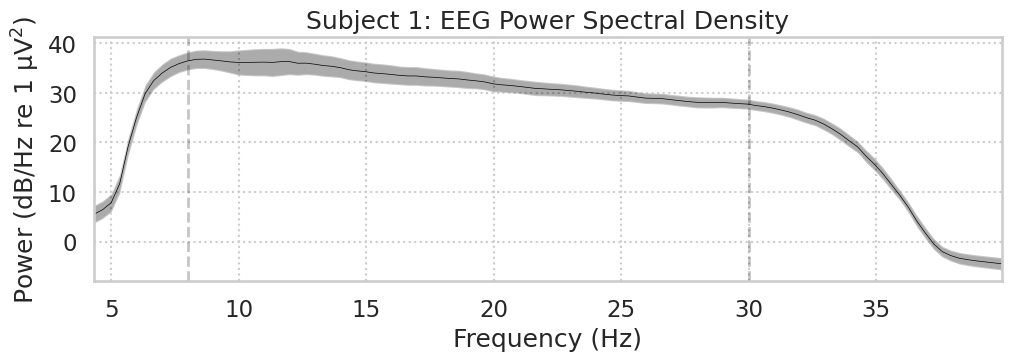

In [5]:
example_subject = next(iter(subject_data))
example_epochs = subject_data[example_subject]["epochs"]

fig = example_epochs.plot_psd(
    fmin=4, fmax=40, average=True, show=False, spatial_colors=False
)
fig.axes[0].set_title(f"Subject {example_subject}: EEG Power Spectral Density")
fig.savefig(FIGURE_DIR / "01_example_power_spectrum.png", dpi=200, bbox_inches="tight")
plt.show()

### Checkpoint

Before continuing, confirm that:

- Every loaded participant has both left- and right-hand trials.
- The number of EEG channels is consistent.
- The power-spectrum figure renders without an error.
- No participant was silently excluded. Any exclusion must be documented.

## 3. Build leakage-safe decoding pipelines

The baseline uses Common Spatial Patterns with shrinkage Linear Discriminant Analysis. The comparison model keeps the same CSP representation and uses regularized logistic regression. All CSP and classifier parameters are learned inside each training fold.

In [7]:
def make_models(n_channels):
    n_components = max(2, min(6, n_channels - 1))
    csp_kwargs = dict(
        n_components=n_components,
        reg="ledoit_wolf",
        log=True,
        norm_trace=False,
    )
    return {
        "CSP + shrinkage LDA": Pipeline([
            ("csp", CSP(**csp_kwargs)),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]),
        "CSP + logistic regression": Pipeline([
            ("csp", CSP(**csp_kwargs)),
            ("scale", StandardScaler()),
            ("logistic", LogisticRegression(
                C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
            )),
        ]),
    }

def participant_cv_predictions(X, y, model):
    min_class = int(np.bincount(y).min())
    n_splits = min(5, min_class)
    if n_splits < 2:
        raise ValueError("Each class needs at least two trials for cross-validation.")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(model, X, y, cv=cv, method="predict", n_jobs=1)

## 4. Benchmark the two decoders across participants

Balanced accuracy is the primary metric because it gives equal weight to the two movement classes. A participant-level analysis is essential: a high group mean can hide users for whom the decoder performs poorly.

In [20]:
benchmark_rows = []
prediction_rows = []

for subject, data in subject_data.items():
    X, y = data["X"], data["y"]
    for model_name, model in make_models(X.shape[1]).items():
        print(f"Benchmarking subject {subject}: {model_name}")
        predictions = participant_cv_predictions(X, y, model)
        benchmark_rows.append({
            "subject": subject,
            "model": model_name,
            "balanced_accuracy": balanced_accuracy_score(y, predictions),
            "f1_score": f1_score(y, predictions, average="macro"),
            "n_trials": len(y),
        })
        prediction_rows.extend([
            {
                "subject": subject,
                "model": model_name,
                "true_label": int(true),
                "predicted_label": int(pred),
            }
            for true, pred in zip(y, predictions)
        ])

benchmark_df = pd.DataFrame(benchmark_rows)
predictions_df = pd.DataFrame(prediction_rows)
benchmark_df.to_csv(RESULTS_DIR / "participant_model_benchmark.csv", index=False)
predictions_df.to_csv(RESULTS_DIR / "out_of_fold_predictions.csv", index=False)

display(benchmark_df.sort_values(["model", "balanced_accuracy"], ascending=[True, False]))
display(benchmark_df.groupby("model")[["balanced_accuracy", "f1_score"]].agg(["mean", "std", "median"]).round(3))

Benchmarking subject 1: CSP + shrinkage LDA
Benchmarking subject 1: CSP + logistic regression
Benchmarking subject 2: CSP + shrinkage LDA
Benchmarking subject 2: CSP + logistic regression
Benchmarking subject 3: CSP + shrinkage LDA
Benchmarking subject 3: CSP + logistic regression
Benchmarking subject 4: CSP + shrinkage LDA
Benchmarking subject 4: CSP + logistic regression
Benchmarking subject 5: CSP + shrinkage LDA
Benchmarking subject 5: CSP + logistic regression
Benchmarking subject 6: CSP + shrinkage LDA
Benchmarking subject 6: CSP + logistic regression
Benchmarking subject 7: CSP + shrinkage LDA
Benchmarking subject 7: CSP + logistic regression
Benchmarking subject 8: CSP + shrinkage LDA
Benchmarking subject 8: CSP + logistic regression
Benchmarking subject 9: CSP + shrinkage LDA
Benchmarking subject 9: CSP + logistic regression
Benchmarking subject 10: CSP + shrinkage LDA
Benchmarking subject 10: CSP + logistic regression
Benchmarking subject 11: CSP + shrinkage LDA
Benchmarking 

,subject,model,balanced_accuracy,f1_score,n_trials
13,7,CSP + logistic regression,0.955534,0.955534,45
3,2,CSP + logistic regression,0.843874,0.844137,45
29,15,CSP + logistic regression,0.708498,0.705882,45
37,19,CSP + logistic regression,0.689723,0.688735,45
1,1,CSP + logistic regression,0.645257,0.644269,45
7,4,CSP + logistic regression,0.621542,0.621475,45
5,3,CSP + logistic regression,0.603755,0.590081,45
15,8,CSP + logistic regression,0.579051,0.576942,45
25,13,CSP + logistic regression,0.578063,0.577778,45
21,11,CSP + logistic regression,0.555336,0.555336,45


balanced_accuracy               f1_score         \
                                       mean    std median     mean    std   
model                                                                       
CSP + logistic regression             0.575  0.146  0.555    0.572  0.146   
CSP + shrinkage LDA                   0.580  0.149  0.555    0.579  0.149   

                                  
                          median  
model                             
CSP + logistic regression  0.554  
CSP + shrinkage LDA        0.554

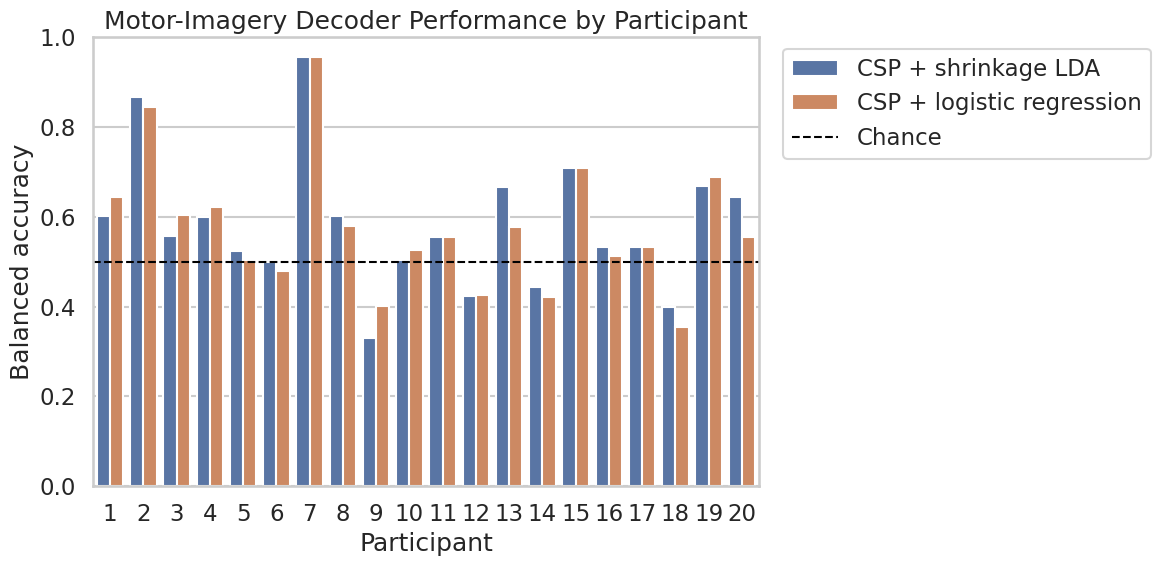

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=benchmark_df,
    x="subject",
    y="balanced_accuracy",
    hue="model",
    ax=ax,
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.5, label="Chance")
ax.set_ylim(0, 1)
ax.set_title("Motor-Imagery Decoder Performance by Participant")
ax.set_xlabel("Participant")
ax.set_ylabel("Balanced accuracy")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_model_performance_by_participant.png", dpi=200, bbox_inches="tight")
plt.show()

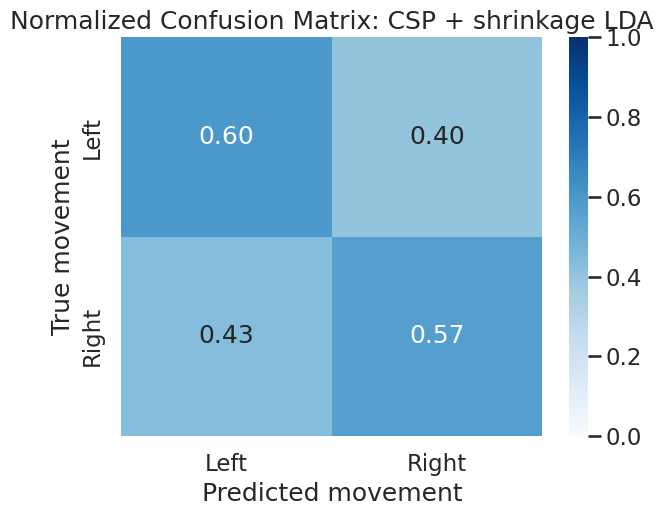

Best development model: CSP + shrinkage LDA


In [21]:
best_model_name = (
    benchmark_df.groupby("model")["balanced_accuracy"].mean().idxmax()
)
best_predictions = predictions_df[predictions_df["model"] == best_model_name]
cm = confusion_matrix(
    best_predictions["true_label"],
    best_predictions["predicted_label"],
    normalize="true",
)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=["Left", "Right"], yticklabels=["Left", "Right"], ax=ax
)
ax.set_title(f"Normalized Confusion Matrix: {best_model_name}")
ax.set_xlabel("Predicted movement")
ax.set_ylabel("True movement")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Best development model: {best_model_name}")

## 5. Measure calibration burden

For each participant, 30% of trials are held out as a fixed test set. The decoder is then trained repeatedly on 25%, 50%, 75%, or 100% of the remaining training data. This estimates the performance cost of shorter calibration sessions.

This is an offline proxy for calibration burden, not a clinical usability study.

In [22]:
CALIBRATION_FRACTIONS = [0.25, 0.50, 0.75, 1.00]
CALIBRATION_REPEATS = 5

def calibration_benchmark(X, y, model, subject):
    outer = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_idx, test_idx = next(outer.split(X, y))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    rows = []

    for fraction in CALIBRATION_FRACTIONS:
        for repeat in range(CALIBRATION_REPEATS):
            if fraction == 1.0:
                subset_X, subset_y = X_train, y_train
            else:
                splitter = StratifiedShuffleSplit(
                    n_splits=1, train_size=fraction, random_state=RANDOM_STATE + repeat
                )
                subset_idx, _ = next(splitter.split(X_train, y_train))
                subset_X, subset_y = X_train[subset_idx], y_train[subset_idx]

            fitted = clone(model).fit(subset_X, subset_y)
            pred = fitted.predict(X_test)
            rows.append({
                "subject": subject,
                "training_fraction": fraction,
                "training_trials": len(subset_y),
                "repeat": repeat,
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            })
    return rows

calibration_rows = []
for subject, data in subject_data.items():
    model = make_models(data["X"].shape[1])[best_model_name]
    print(f"Calibration analysis: subject {subject}")
    calibration_rows.extend(
        calibration_benchmark(data["X"], data["y"], model, subject)
    )

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(RESULTS_DIR / "calibration_burden_results.csv", index=False)
display(calibration_df.groupby("training_fraction")[["training_trials", "balanced_accuracy"]].mean().round(3))

Calibration analysis: subject 1
Calibration analysis: subject 2
Calibration analysis: subject 3
Calibration analysis: subject 4
Calibration analysis: subject 5
Calibration analysis: subject 6
Calibration analysis: subject 7
Calibration analysis: subject 8
Calibration analysis: subject 9
Calibration analysis: subject 10
Calibration analysis: subject 11
Calibration analysis: subject 12
Calibration analysis: subject 13
Calibration analysis: subject 14
Calibration analysis: subject 15
Calibration analysis: subject 16
Calibration analysis: subject 17
Calibration analysis: subject 18
Calibration analysis: subject 19
Calibration analysis: subject 20


,training_trials,balanced_accuracy
training_fraction,,
0.25,7.0,0.488
0.50,15.0,0.534
0.75,23.0,0.576
1.00,31.0,0.582


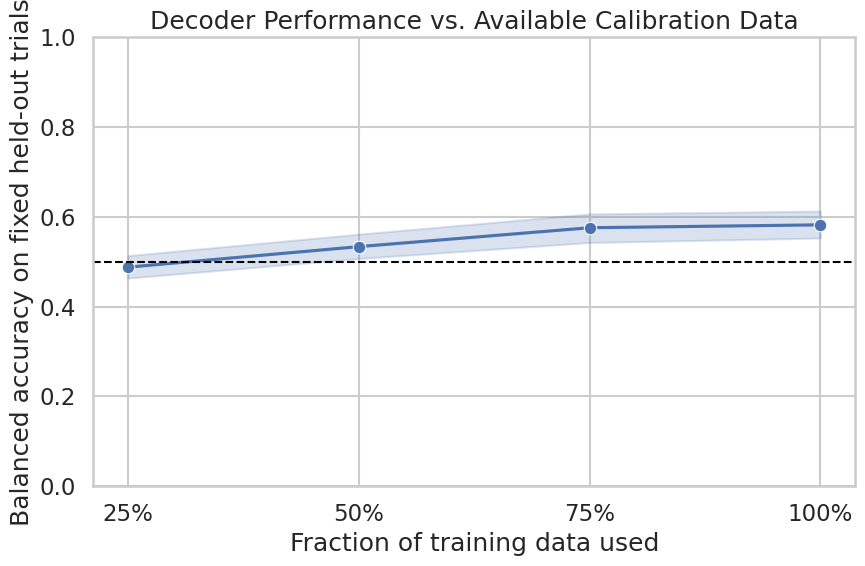

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(
    data=calibration_df,
    x="training_fraction",
    y="balanced_accuracy",
    marker="o",
    errorbar=("ci", 95),
    ax=ax,
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_xticks(CALIBRATION_FRACTIONS, ["25%", "50%", "75%", "100%"])
ax.set_ylim(0, 1)
ax.set_title("Decoder Performance vs. Available Calibration Data")
ax.set_xlabel("Fraction of training data used")
ax.set_ylabel("Balanced accuracy on fixed held-out trials")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_calibration_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Evaluate the electrode-count tradeoff

This section compares all available EEG electrodes with 16- and 8-channel motor-region subsets. It tests whether a simpler recording setup retains useful decoding performance.

Electrode reduction in scalp EEG is not equivalent to changing the channel count of an implanted interface. This analysis demonstrates tradeoff reasoning, not a claim about Neuralace or another intracortical platform.

In [24]:
MOTOR_16 = [
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C3", "C1", "Cz", "C2", "C4",
    "CP3", "CP1", "CPz", "CP2", "CP4", "Pz",
]
MOTOR_8 = ["FC3", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"]

def channel_indices(ch_names, requested):
    lookup = {name.lower(): idx for idx, name in enumerate(ch_names)}
    indices = [lookup[name.lower()] for name in requested if name.lower() in lookup]
    missing = [name for name in requested if name.lower() not in lookup]
    if missing:
        print(f"Channels not found and omitted: {missing}")
    return indices

channel_rows = []
for subject, data in subject_data.items():
    X, y, names = data["X"], data["y"], data["ch_names"]
    channel_sets = {
        "All channels": list(range(len(names))),
        "16 motor-region channels": channel_indices(names, MOTOR_16),
        "8 motor-region channels": channel_indices(names, MOTOR_8),
    }
    for set_name, indices in channel_sets.items():
        if len(indices) < 4:
            print(f"Skipping {set_name} for subject {subject}: too few channels found.")
            continue
        subset_X = X[:, indices, :]
        model = make_models(subset_X.shape[1])[best_model_name]
        pred = participant_cv_predictions(subset_X, y, model)
        channel_rows.append({
            "subject": subject,
            "channel_set": set_name,
            "n_channels": len(indices),
            "balanced_accuracy": balanced_accuracy_score(y, pred),
        })

channel_df = pd.DataFrame(channel_rows)
channel_df.to_csv(RESULTS_DIR / "channel_tradeoff_results.csv", index=False)
display(channel_df.groupby(["channel_set", "n_channels"])["balanced_accuracy"].agg(["mean", "std", "median"]).round(3))

,,mean,std,median
channel_set,n_channels,,,
16 motor-region channels,16,0.583,0.175,0.554
8 motor-region channels,8,0.588,0.186,0.544
All channels,64,0.580,0.149,0.555


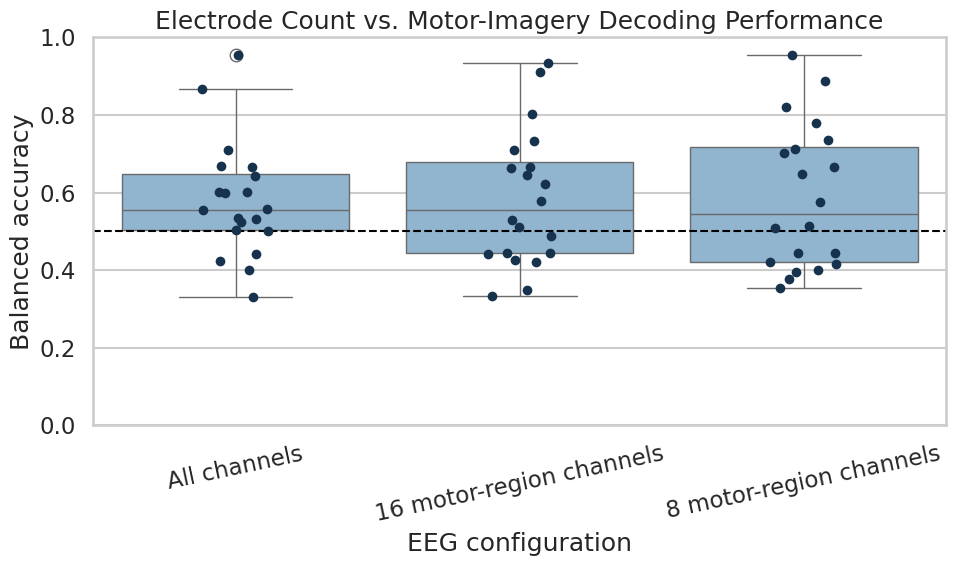

In [26]:
channel_order = ["All channels", "16 motor-region channels", "8 motor-region channels"]
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=channel_df, x="channel_set", y="balanced_accuracy",
    order=channel_order, color="#87b6d9", ax=ax
)
sns.stripplot(
    data=channel_df, x="channel_set", y="balanced_accuracy",
    order=channel_order, color="#17324d", size=7, jitter=0.12, ax=ax
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_ylim(0, 1)
ax.set_title("Electrode Count vs. Motor-Imagery Decoding Performance")
ax.set_xlabel("EEG configuration")
ax.set_ylabel("Balanced accuracy")
ax.tick_params(axis="x", rotation=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_channel_count_tradeoff.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Create the final result summary

The next cell produces a machine-readable summary. Do not copy any number into a résumé or README until you have completed the larger run and reviewed the data-quality table.

In [27]:
model_summary = (
    benchmark_df.groupby("model")
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        median_balanced_accuracy=("balanced_accuracy", "median"),
        mean_f1=("f1_score", "mean"),
        participants=("subject", "nunique"),
    )
    .reset_index()
)
model_summary.to_csv(RESULTS_DIR / "model_summary.csv", index=False)

summary = {
    "participants_analyzed": int(benchmark_df["subject"].nunique()),
    "best_model": best_model_name,
    "best_model_mean_balanced_accuracy": float(
        benchmark_df.loc[benchmark_df["model"] == best_model_name, "balanced_accuracy"].mean()
    ),
    "best_model_std_balanced_accuracy": float(
        benchmark_df.loc[benchmark_df["model"] == best_model_name, "balanced_accuracy"].std()
    ),
    "filter_band_hz": [FMIN, FMAX],
    "epoch_window_seconds": [TMIN, TMAX],
    "imagery_runs": RUNS,
}
with open(RESULTS_DIR / "project_summary.json", "w") as file:
    json.dump(summary, file, indent=2)

display(model_summary.round(3))
print(json.dumps(summary, indent=2))

,model,mean_balanced_accuracy,std_balanced_accuracy,median_balanced_accuracy,mean_f1,participants
0,CSP + logistic regression,0.575,0.146,0.555,0.572,20
1,CSP + shrinkage LDA,0.580,0.149,0.555,0.579,20


{
  "participants_analyzed": 20,
  "best_model": "CSP + shrinkage LDA",
  "best_model_mean_balanced_accuracy": 0.5804406644080556,
  "best_model_std_balanced_accuracy": 0.14865237649845398,
  "filter_band_hz": [
    8.0,
    30.0
  ],
  "epoch_window_seconds": [
    0.5,
    3.5
  ],
  "imagery_runs": [
    4,
    8,
    12
  ]
}


## 8. What I took from the results

The five-participant pipeline check initially favored logistic regression. After expanding to 20 participants, LDA had the slightly higher mean, but the paired difference was negligible. That reversal is a useful warning against choosing a model from a small pilot.

Participant variation was the dominant result. Some people decoded well while others remained at or below chance. For a practical BCI, I would want to report the percentage of users who reach a predefined control threshold, not only the group average.

The calibration curve improved through 75% of the available training data and then changed very little. Reduced channel sets also preserved the cohort mean, although their participant-level spread was wider. Neither result proves that shorter calibration or fewer electrodes are equivalent. They identify two tradeoffs worth testing prospectively with setup time, comfort, signal quality, and day-to-day stability measured alongside accuracy.

This remains an offline scalp-EEG analysis of a controlled imagery task. It is not evidence about clinical effectiveness, asynchronous control, or implanted BCI performance.

## 9. Save and download the portfolio outputs

Run the next cell after confirming that every result and figure is valid. It creates a ZIP file containing the figures and CSV/JSON outputs.

In [30]:
import shutil
from pathlib import Path

export_dir = Path("/content/bci_portfolio_outputs")
(export_dir / "figures").mkdir(parents=True, exist_ok=True)
(export_dir / "results").mkdir(parents=True, exist_ok=True)

for file in FIGURE_DIR.glob("*"):
    shutil.copy2(file, export_dir / "figures" / file.name)

for file in RESULTS_DIR.glob("*"):
    shutil.copy2(file, export_dir / "results" / file.name)

archive_path = shutil.make_archive(
    "/content/bci_portfolio_outputs",
    "zip",
    export_dir
)

from google.colab import files
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Reproducibility and scope notes

The saved notebook contains the completed 20-participant run. Participant-level metrics, out-of-fold predictions, calibration subsets, and channel comparisons are exported as CSV files rather than copied by hand. The repository excludes the downloaded EDF recordings, which MNE retrieves from PhysioNet when the notebook is run.

The statistical checks in the repository aggregate repeated results by participant. This avoids treating trials or repeated calibration subsets from the same person as independent samples.